# EDA — Dataset Lung Cancer CT Images

Notebook ini melakukan eksplorasi data awal (EDA) terhadap dataset citra paru-paru (Kaggle: `xiaopengzhang12/lung-cancer-mri-images`) sebelum masuk ke tahap stratified split dan training.

> **Koreksi modalitas citra:** dataset ini diberi nama "Lung Cancer **MRI** Images" oleh uploader-nya di Kaggle, tapi Bagian 0 di bawah menunjukkan bukti visual bahwa seluruh citra sebenarnya adalah **CT scan**, bukan MRI. Sisa notebook ini (dan seluruh penelitian) memakai istilah "CT" yang sudah dikoreksi, meskipun nama folder/file mentah di disk masih memakai nama asli "MRI" dari dataset sumber.

Tujuan:
0. Verifikasi modalitas citra sebenarnya (MRI vs CT).
1. Membangun manifest lengkap seluruh citra (path, kelas, split asal, format file).
2. Memverifikasi jumlah citra per kelas dan per split asal (`train` / `validate`).
3. Mengidentifikasi 12 file JPG yang menjadi anomali format di tengah dominasi PNG.
4. Memverifikasi integritas seluruh file citra (tidak korup).
5. Menganalisis dimensi dan mode warna citra.
6. Visualisasi sample citra per kelas.
7. Menyimpan ringkasan EDA untuk dipakai di Bab IV skripsi.


In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATASET_ROOT = Path("../dataset/lung_cancer_MRI_dataset")
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

SPLITS = ["train", "validate"]
CLASSES = ["cancer", "no_cancer"]

print("Dataset root:", DATASET_ROOT.resolve())


Dataset root: D:\skripsi\dataset\lung_cancer_MRI_dataset


## 0. Investigasi modalitas citra — MRI atau CT?

Sebelum menganalisis apapun, penting untuk memverifikasi klaim dasar dataset: apakah citra ini benar-benar MRI seperti nama datasetnya? Tiga ciri visual berikut membedakan CT dari MRI secara definitif:

1. **Field-of-view (FOV) berbentuk lingkaran dengan sudut hitam** — artefak khas rekonstruksi CT fan-beam. MRI tidak memiliki pola crop seperti ini.
2. **Tulang tampak putih terang (sinyal/densitas tinggi)** — khas CT (bone window). Di MRI, tulang kortikal justru tampak gelap (sinyal rendah, sedikit air/lemak).
3. **Windowing paru klasik** — jaringan paru gelap dengan percabangan vaskular/bronkus sangat detail, mediastinum & trakea jelas di tengah. Ini pola "lung window" CT, bukan sekuens MRI (T1/T2/PD) manapun.


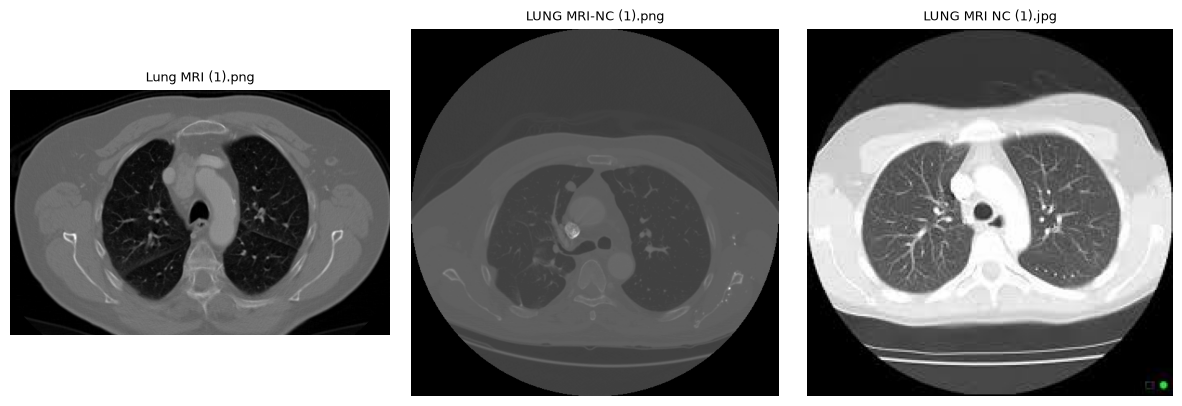

In [2]:
sample_paths = [
    DATASET_ROOT / "train" / "cancer" / "Lung MRI (1).png",
    DATASET_ROOT / "train" / "no_cancer" / "LUNG MRI-NC (1).png",
    DATASET_ROOT / "validate" / "no_cancer" / "LUNG MRI NC (1).jpg",
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, path in zip(axes, sample_paths):
    img = Image.open(path)
    ax.imshow(img, cmap="gray")
    ax.set_title(path.name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "modality_check_samples.png", dpi=150)
plt.show()


**Kesimpulan:** ketiga sampel di atas (dari kelas dan split berbeda) semuanya menunjukkan FOV lingkaran khas rekonstruksi CT, tulang rusuk bersinyal tinggi, dan windowing paru klasik CT. Dataset ini adalah **citra CT**, bukan MRI. Penelitian ini selanjutnya mengoreksi terminologi menjadi "citra CT" di seluruh dokumentasi dan penulisan skripsi (lihat README.md), meskipun nama file/folder mentah di dataset asli tetap memakai kata "MRI" dari sumber Kaggle.


## 1. Membangun manifest file

In [3]:
records = []
for split in SPLITS:
    for label in CLASSES:
        folder = DATASET_ROOT / split / label
        for path in folder.iterdir():
            if path.is_file():
                records.append({
                    "split": split,
                    "label": label,
                    "filename": path.name,
                    "ext": path.suffix.lower(),
                    "path": str(path),
                })

manifest = pd.DataFrame(records)
print(f"Total citra ditemukan: {len(manifest)}")
manifest.head()


Total citra ditemukan: 3680


,split,label,filename,ext,path
0,train,cancer,Lung MRI (1).png,.png,..\dataset\lung_cancer_MRI_dataset\train\cance...
1,train,cancer,Lung MRI (10).png,.png,..\dataset\lung_cancer_MRI_dataset\train\cance...
2,train,cancer,Lung MRI (100).png,.png,..\dataset\lung_cancer_MRI_dataset\train\cance...
3,train,cancer,Lung MRI (1000).png,.png,..\dataset\lung_cancer_MRI_dataset\train\cance...
4,train,cancer,Lung MRI (1001).png,.png,..\dataset\lung_cancer_MRI_dataset\train\cance...


## 2. Distribusi kelas & split

label,cancer,no_cancer,total
split,,,
train,1122,1314,2436
validate,752,492,1244



Total per kelas (gabungan train+validate):
label
cancer       1874
no_cancer    1806
Name: count, dtype: int64


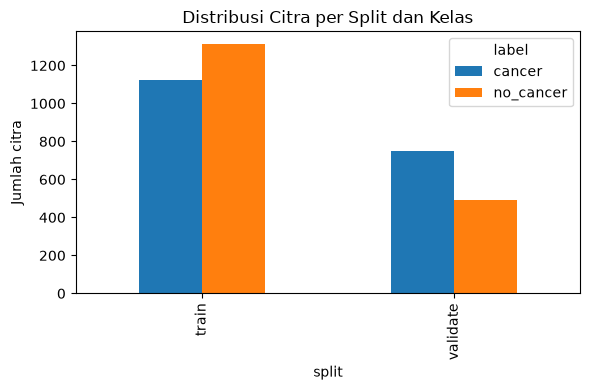

In [4]:
dist = manifest.groupby(["split", "label"]).size().unstack(fill_value=0)
dist["total"] = dist.sum(axis=1)
display(dist)

print("\nTotal per kelas (gabungan train+validate):")
print(manifest["label"].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
manifest.groupby(["split", "label"]).size().unstack().plot(kind="bar", ax=ax)
ax.set_title("Distribusi Citra per Split dan Kelas")
ax.set_ylabel("Jumlah citra")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "class_distribution.png", dpi=150)
plt.show()


## 3. Anomali format — file JPG di antara dominasi PNG

In [5]:
ext_counts = manifest["ext"].value_counts()
print(ext_counts)

jpg_anomalies = manifest[manifest["ext"].isin([".jpg", ".jpeg"])]
print(f"\nJumlah file JPG/JPEG: {len(jpg_anomalies)}")
jpg_anomalies[["split", "label", "filename"]]


ext
.png    3668
.jpg      12
Name: count, dtype: int64



Jumlah file JPG/JPEG: 12


,split,label,filename
3188,validate,no_cancer,LUNG MRI NC (1).jpg
3190,validate,no_cancer,LUNG MRI NC (10).jpg
3202,validate,no_cancer,LUNG MRI NC (11).jpg
3214,validate,no_cancer,LUNG MRI NC (12).jpg
3303,validate,no_cancer,LUNG MRI NC (2).jpg
3415,validate,no_cancer,LUNG MRI NC (3).jpg
3527,validate,no_cancer,LUNG MRI NC (4).jpg
3620,validate,no_cancer,LUNG MRI NC (5).jpg
3632,validate,no_cancer,LUNG MRI NC (6).jpg
3644,validate,no_cancer,LUNG MRI NC (7).jpg


## 4. Verifikasi integritas file (deteksi file korup)

In [6]:
corrupt_files = []
for path in manifest["path"]:
    try:
        with Image.open(path) as im:
            im.verify()
    except Exception as e:
        corrupt_files.append((path, str(e)))

print(f"File korup ditemukan: {len(corrupt_files)}")
for p, err in corrupt_files:
    print(p, "->", err)


File korup ditemukan: 0


## 5. Dimensi dan mode warna citra

In [7]:
def get_image_info(path):
    with Image.open(path) as im:
        return im.size[0], im.size[1], im.mode

info = manifest["path"].apply(get_image_info)
manifest["width"] = info.apply(lambda x: x[0])
manifest["height"] = info.apply(lambda x: x[1])
manifest["mode"] = info.apply(lambda x: x[2])

manifest[["width", "height"]].describe()


,width,height
count,3680.000000,3680.000000
mean,478.038859,428.831793
std,77.737519,116.151281
min,168.000000,110.000000
25%,429.000000,310.000000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,1200.000000,874.000000


In [8]:
print("Mode warna:")
print(manifest["mode"].value_counts())

print("\nUkuran citra unik (width x height), top 10:")
print(manifest.groupby(["width", "height"]).size().sort_values(ascending=False).head(10))

print("\nDimensi khusus file JPG anomali:")
manifest[manifest["ext"].isin([".jpg", ".jpeg"])][["filename", "width", "height", "mode"]]


Mode warna:
mode
RGBA    3599
RGB       77
L          4
Name: count, dtype: int64

Ukuran citra unik (width x height), top 10:
width  height
512    512       2230
800    577          9
       552          9
443    344          8
438    338          8
371    251          8
850    506          8
393    270          8
630    626          6
366    234          6
dtype: int64

Dimensi khusus file JPG anomali:


,filename,width,height,mode
3188,LUNG MRI NC (1).jpg,224,225,RGB
3190,LUNG MRI NC (10).jpg,400,358,RGB
3202,LUNG MRI NC (11).jpg,400,358,RGB
3214,LUNG MRI NC (12).jpg,400,358,RGB
3303,LUNG MRI NC (2).jpg,224,225,RGB
3415,LUNG MRI NC (3).jpg,224,225,RGB
3527,LUNG MRI NC (4).jpg,224,225,RGB
3620,LUNG MRI NC (5).jpg,800,552,RGB
3632,LUNG MRI NC (6).jpg,800,552,RGB
3644,LUNG MRI NC (7).jpg,800,552,RGB


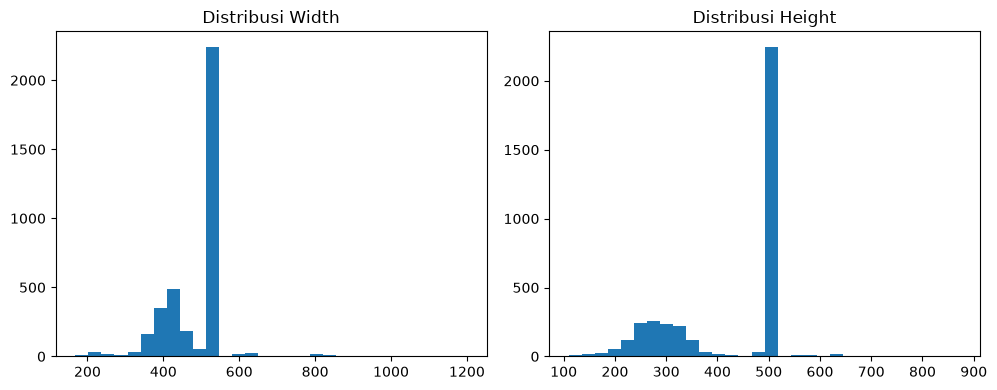

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(manifest["width"], bins=30)
axes[0].set_title("Distribusi Width")
axes[1].hist(manifest["height"], bins=30)
axes[1].set_title("Distribusi Height")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "image_size_distribution.png", dpi=150)
plt.show()


## 6. Visualisasi sample per kelas

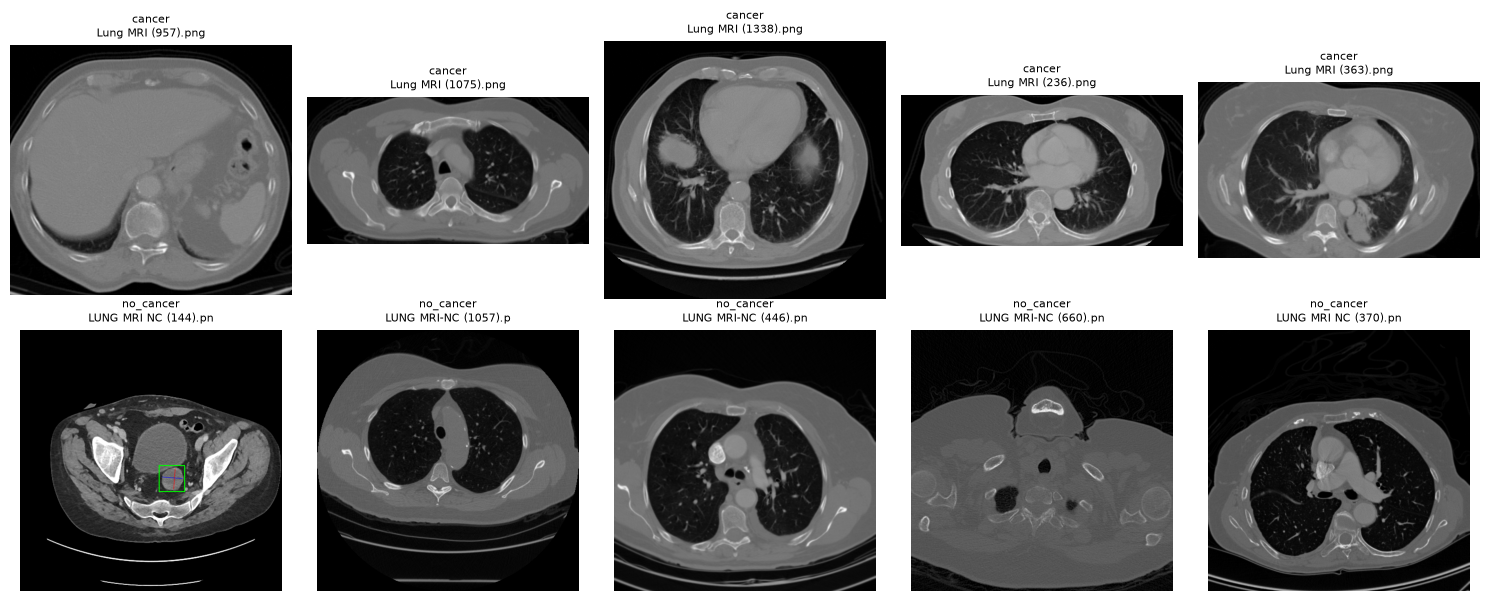

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, label in enumerate(CLASSES):
    samples = manifest[manifest["label"] == label].sample(5, random_state=RANDOM_SEED)
    for col, (_, row_data) in enumerate(samples.iterrows()):
        img = Image.open(row_data["path"])
        axes[row, col].imshow(img, cmap="gray" if img.mode == "L" else None)
        axes[row, col].set_title(f"{label}\n{row_data['filename'][:20]}", fontsize=8)
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "sample_grid.png", dpi=150)
plt.show()


## 7. Simpan ringkasan EDA

In [11]:
summary = {
    "modality_corrected_to": "CT",
    "modality_original_claim": "MRI",
    "total_images": int(len(manifest)),
    "per_label": manifest["label"].value_counts().to_dict(),
    "per_split": manifest["split"].value_counts().to_dict(),
    "per_split_label": manifest.groupby(["split", "label"]).size().unstack(fill_value=0).to_dict(),
    "extension_counts": manifest["ext"].value_counts().to_dict(),
    "jpg_anomaly_count": int(len(jpg_anomalies)),
    "corrupt_file_count": len(corrupt_files),
    "width_stats": manifest["width"].describe().to_dict(),
    "height_stats": manifest["height"].describe().to_dict(),
    "color_mode_counts": manifest["mode"].value_counts().to_dict(),
}

with open(REPORTS_DIR / "eda_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

manifest.to_csv(REPORTS_DIR / "dataset_manifest.csv", index=False)

print("Ringkasan EDA disimpan ke reports/eda_summary.json")
print("Manifest lengkap disimpan ke reports/dataset_manifest.csv")
summary


Ringkasan EDA disimpan ke reports/eda_summary.json
Manifest lengkap disimpan ke reports/dataset_manifest.csv


{'modality_corrected_to': 'CT',
 'modality_original_claim': 'MRI',
 'total_images': 3680,
 'per_label': {'cancer': 1874, 'no_cancer': 1806},
 'per_split': {'train': 2436, 'validate': 1244},
 'per_split_label': {'cancer': {'train': 1122, 'validate': 752},
  'no_cancer': {'train': 1314, 'validate': 492}},
 'extension_counts': {'.png': 3668, '.jpg': 12},
 'jpg_anomaly_count': 12,
 'corrupt_file_count': 0,
 'width_stats': {'count': 3680.0,
  'mean': 478.03885869565215,
  'std': 77.73751920848777,
  'min': 168.0,
  '25%': 429.0,
  '50%': 512.0,
  '75%': 512.0,
  'max': 1200.0},
 'height_stats': {'count': 3680.0,
  'mean': 428.83179347826086,
  'std': 116.15128113270863,
  'min': 110.0,
  '25%': 310.0,
  '50%': 512.0,
  '75%': 512.0,
  'max': 874.0},
 'color_mode_counts': {'RGBA': 3599, 'RGB': 77, 'L': 4}}